### Predictive Model
* Gene expression: log2 normalization, top 10% expression levels and variance -> Struggling to integrate this
* Mutation data: Missense|Nonsense|Frame_Shift|Splice|In_Frame counts per patient per gene (NS mutations), taking top 10 IntOGen genes
* Metatdata: age at diagnosis, gender, stage, histological grade
* Predict: DSS - predict likelihood of disease-specific death within 2 years
* Check: ROC_AUC, balance classes, balanced accuracy -> avoid overfitting

In [1]:
import pandas as pd
import numpy as np

# Load data
expr = pd.read_csv('Team_4_STAD/TCGA.STAD.expression.txt', sep='\t')
mut = pd.read_csv('Team_4_STAD/TCGA.STAD.mutations.txt', sep='\t')     
meta = pd.read_csv('Team_4_STAD/TCGA.STAD.metadata.txt', sep='\t')

# List of patients with valid DSS data
meta = meta.dropna(subset=['DSS', 'DSS.time'])
valid_patients = set(meta['patient_id'])

expr = expr[expr['patient_id'].isin(valid_patients)].copy()
mut = mut[mut['patient_id'].isin(valid_patients)].copy()

len(valid_patients)

386

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

columns_to_drop = [col for col in expr.columns if "?" in col]
expr = expr.drop(columns=columns_to_drop, axis=1)

# Log2 transformation for expression
expr_genes = expr.columns[2:]  # gene columns start after sample columns
expr[expr_genes] = np.log2(expr[expr_genes] + 1)

# Retain genes expressed in at least 10% of patients and top 10% variance
def filter_expression(df, min_expr=1, min_pct=0.1, top_var=0.05):
    gene_cols = df.columns[2:]
    mask = (df[gene_cols] > min_expr).mean() >= min_pct
    filtered = df[gene_cols].loc[:, mask]
    variances = filtered.var().sort_values(ascending=False)
    top_genes = variances.head(int(top_var * len(variances))).index
    return df[['patient_id', 'sample_id'] + list(top_genes)]

expr_filt = filter_expression(expr)

expr_genes = expr_filt.columns[2:]  # assuming IDs are first two columns
ids = expr_filt[['patient_id', 'sample_id']]
expr_values = expr_filt[expr_genes]

# Impute missing values
imputer = KNNImputer(n_neighbors=5)
imputed_expr = imputer.fit_transform(expr_values)

scaler = StandardScaler()
expr_scaled = scaler.fit_transform(imputed_expr)

# Convert scaled values back to DataFrame and restore column names
expr_df = pd.DataFrame(expr_scaled, columns=expr_genes, index=expr_filt.index)

# Combine with metadata
expression = pd.concat([ids, expr_df], axis=1)

# Number of PCs to keep (choose as needed)
n_components = 10  # Or set to None to keep all, or use explained_variance_ratio_ to decide

# Fit PCA on scaled expression data
pca = PCA(n_components=n_components)
pcs = pca.fit_transform(expr_df.values)

# Create DataFrame with PC columns
pc_columns = [f'PC{i+1}' for i in range(pcs.shape[1])]
pcs_df = pd.DataFrame(pcs, columns=pc_columns, index=expr_df.index)

# Combine with IDs (optional)
pca_with_ids = pd.concat([ids.reset_index(drop=True), pcs_df.reset_index(drop=True)], axis=1)

# Show result
pca_with_ids.head()

,patient_id,sample_id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,TCGA-CG-4460,TCGA-CG-4460-01A-01R-1157-13,-0.221099,11.074332,6.681070,4.907094,-10.866331,2.150376,-11.707278,3.097772,1.052947,1.106711
1,TCGA-CG-5716,TCGA-CG-5716-01A-21R-1802-13,-1.201939,15.350338,1.616366,-11.842661,-8.696956,-2.395835,-6.087233,-2.381801,4.366699,3.481367
2,TCGA-3M-AB46,TCGA-3M-AB46-01A-11R-A414-31,-13.378082,-1.557211,0.289576,4.214266,4.044263,2.173765,-0.522219,-2.438035,-3.287082,-0.653830
3,TCGA-B7-5816,TCGA-B7-5816-01A-21R-1602-13,-3.451911,-9.920557,-3.018927,-4.475718,-1.761077,8.448623,2.021459,6.905220,2.833426,-2.718380
4,TCGA-B7-5818,TCGA-B7-5818-01A-11R-1602-13,-6.563387,-18.828996,-5.196577,-6.223299,-6.708239,-6.250962,12.363042,-0.062166,-2.977431,-1.630553


In [3]:
## Update this to be mutation counts??

# Binary mutation features: for each gene, 1 if mutated in patient
def mutation_matrix(mut_df, min_patients=5):
    mut_df = mut_df[mut_df['Variant_Classification'].str.contains('Missense|Nonsense|Frame_Shift|Splice|In_Frame|Frame_Shift', na=False)]
    mut_pivot = pd.pivot_table(mut_df, index='patient_id', columns='Hugo_Symbol', values='Variant_Classification', aggfunc='count', fill_value=0)
    mut_pivot = (mut_pivot > 0).astype(int) # this part binarizes
    # Filter genes mutated in at least min_patients
    keep = mut_pivot.sum() >= min_patients
    return mut_pivot.loc[:, keep]

mut_bin = mutation_matrix(mut)

# TP53, CSMD3, FAT4, ARID1A, PIK3CA, ERBB4, APC, CDH1, SMAD4, KMT2D (TCGA.STAD dataset)
genes_of_interest = [
    'TP53', 'CSMD3', 'FAT4', 'ARID1A', 'PIK3CA', 
    'ERBB4', 'APC', 'CDH1', 'SMAD4', 'KMT2D'
]

genes_to_keep = [g for g in genes_of_interest if g in mut_bin.columns]
mut_bin_filtered = mut_bin[genes_to_keep]

mut_bin_filtered

Hugo_Symbol,TP53,CSMD3,FAT4,ARID1A,PIK3CA,ERBB4,APC,CDH1,SMAD4,KMT2D
patient_id,,,,,,,,,,
TCGA-3M-AB46,1,1,0,0,0,0,0,0,0,0
TCGA-B7-5816,0,0,1,1,1,1,0,0,0,0
TCGA-B7-5818,1,0,0,1,1,0,0,0,0,0
TCGA-B7-A5TI,1,0,1,1,0,0,0,1,0,1
TCGA-B7-A5TJ,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6G,1,0,0,0,0,0,0,0,0,0
TCGA-VQ-AA6I,1,0,0,0,0,0,0,0,0,0
TCGA-VQ-AA6J,0,1,0,1,0,0,0,0,0,0


In [4]:
# Use age, gender, stage, grade as numeric/categorical predictors
meta_sel = meta[['patient_id', 'age_at_initial_pathologic_diagnosis', 'gender', 
                 'ajcc_pathologic_tumor_stage', 'histological_grade', 'DSS','DSS.time']].copy()

# Encode categoricals
meta_sel['gender'] = meta_sel['gender'].str.strip().str.lower().map({'male': 0, 'female': 1})
meta_sel = pd.get_dummies(meta_sel, columns=['ajcc_pathologic_tumor_stage', 'histological_grade'], drop_first=True)

# Merge all features by patient_id
df = meta_sel.merge(mut_bin_filtered, left_on='patient_id', right_index=True, how='left').fillna(0)
# .merge(pca_with_ids, on='patient_id', how='left') # expression data not doing too hot
df

,patient_id,age_at_initial_pathologic_diagnosis,gender,DSS,DSS.time,ajcc_pathologic_tumor_stage_Stage IA,ajcc_pathologic_tumor_stage_Stage IB,ajcc_pathologic_tumor_stage_Stage II,ajcc_pathologic_tumor_stage_Stage IIA,ajcc_pathologic_tumor_stage_Stage IIB,...,TP53,CSMD3,FAT4,ARID1A,PIK3CA,ERBB4,APC,CDH1,SMAD4,KMT2D
0,TCGA-3M-AB46,70.0,0,0.0,1765.0,False,True,False,False,False,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,TCGA-B7-5816,51.0,1,0.0,812.0,False,False,False,False,True,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
3,TCGA-B7-5818,62.0,0,0.0,356.0,False,True,False,False,False,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,TCGA-B7-A5TI,52.0,0,0.0,595.0,False,False,False,False,False,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
5,TCGA-B7-A5TJ,74.0,0,0.0,335.0,False,False,False,False,True,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,TCGA-VQ-AA6G,68.0,0,1.0,792.0,False,False,False,True,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
410,TCGA-VQ-AA6I,68.0,0,1.0,491.0,False,False,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
411,TCGA-VQ-AA6J,75.0,0,0.0,838.0,False,False,False,False,False,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
412,TCGA-VQ-AA6K,59.0,0,1.0,378.0,False,False,False,False,False,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [5]:
## NEED TO ONLY CONSIDER DATA WITH DSS DATA FOR VALIDATING

# Label: 1 if recurrence/metastasis/new tumor event within 5 years (1825 days), else 0
df['DSS_event'] = ((df['DSS'] == 1) & (df['DSS.time'] <= 1825)).astype(int)
df['DSS_censored'] = ((df['DSS'] == 0) | (df['DSS.time'] > 1825)).astype(int)
df = df.dropna(subset=['DSS_event'])

print(df['DSS_event'].sum())
print(df['DSS_censored'].sum())
print(df['DSS_event'].sum()/df['DSS_censored'].sum())

94
292
0.3219178082191781


### Manually balance (resample) & split into test and train data
* downsample negative cases to more closely match the number of positive cases

In [6]:
from sklearn.utils import resample

n_samples = min(df['DSS_event'].sum(), df['DSS_censored'].sum())

# Downsample each class to the same number of samples
positive_bal = resample(df[df['DSS_event'] ==1], replace=False, n_samples=n_samples, random_state=42)
negative_bal = resample(df[df['DSS_censored'] == 1], replace=False, n_samples=n_samples, random_state=42)

import pandas as pd

df_balanced = pd.concat([positive_bal, negative_bal]).sample(frac=1, random_state=42).reset_index(drop=True)

from sklearn.model_selection import train_test_split

X = df_balanced.drop(['patient_id', 'DSS', 'DSS.time', 'DSS_event', 'DSS_censored'], axis=1)
y = df_balanced['DSS_event']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

print(df_balanced['DSS_event'].sum())
print(df_balanced['DSS_censored'].sum())
print(df_balanced['DSS_event'].sum()/df_balanced['DSS_censored'].sum())


94
94
1.0


### Quick Benchmarking

In [7]:
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=1, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
print(models.sort_values(by='ROC AUC', ascending=False).head())

  0%|          | 0/32 [00:00<?, ?it/s]

{'Model': 'AdaBoostClassifier', 'Accuracy': 0.5526315789473685, 'Balanced Accuracy': np.float64(0.5526315789473684), 'ROC AUC': np.float64(0.5526315789473685), 'F1 Score': 0.5523215523215523, 'Time taken': 0.05176711082458496}
{'Model': 'BaggingClassifier', 'Accuracy': 0.5, 'Balanced Accuracy': np.float64(0.5), 'ROC AUC': np.float64(0.5), 'F1 Score': 0.482437275985663, 'Time taken': 0.01670384407043457}
{'Model': 'BernoulliNB', 'Accuracy': 0.47368421052631576, 'Balanced Accuracy': np.float64(0.47368421052631576), 'ROC AUC': np.float64(0.47368421052631576), 'F1 Score': 0.47368421052631576, 'Time taken': 0.0048639774322509766}
{'Model': 'CalibratedClassifierCV', 'Accuracy': 0.5789473684210527, 'Balanced Accuracy': np.float64(0.5789473684210527), 'ROC AUC': np.float64(0.5789473684210527), 'F1 Score': 0.5777777777777778, 'Time taken': 0.018234968185424805}
{'Model': 'DecisionTreeClassifier', 'Accuracy': 0.4473684210526316, 'Balanced Accuracy': np.float64(0.4473684210526315), 'ROC AUC': np.

In [8]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NuSVC,0.68,0.68,0.68,0.68,0.01
SVC,0.61,0.61,0.61,0.60,0.01
PassiveAggressiveClassifier,0.61,0.61,0.61,0.60,0.01
LabelPropagation,0.61,0.61,0.61,0.60,0.01
LinearSVC,0.58,0.58,0.58,0.58,0.00
LinearDiscriminantAnalysis,0.58,0.58,0.58,0.58,0.00
CalibratedClassifierCV,0.58,0.58,0.58,0.58,0.02
RidgeClassifierCV,0.58,0.58,0.58,0.58,0.01
RidgeClassifier,0.58,0.58,0.58,0.58,0.01


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, auc

# Feature selection with RandomForest
fs_rf = RandomForestClassifier(n_estimators=100, random_state=42)
fs_rf.fit(X_train, y_train)
sel = SelectFromModel(fs_rf, threshold='median', prefit=True)
X_train_sel = sel.transform(X_train)
X_test_sel = sel.transform(X_test)

# Hyperparameter tuning
param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 5, 10]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=cv, scoring='roc_auc')
grid.fit(X_train_sel, y_train)
best_rf = grid.best_estimator_
print("Best parameters:", grid.best_params_)

# Predict/test
y_pred = best_rf.predict(X_test_sel)
y_prob = best_rf.predict_proba(X_test_sel)[:, 1]
print(classification_report(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))

Best parameters: {'max_depth': 10, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.61      0.74      0.67        19
           1       0.67      0.53      0.59        19

    accuracy                           0.63        38
   macro avg       0.64      0.63      0.63        38
weighted avg       0.64      0.63      0.63        38

Test ROC-AUC: 0.6592797783933517


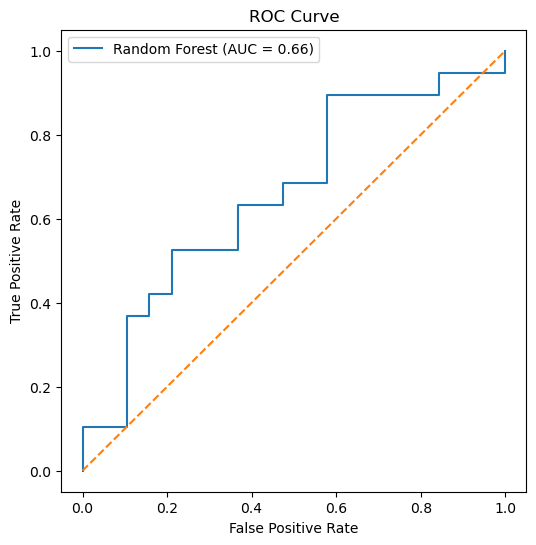

In [10]:
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label='Random Forest (AUC = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve')
plt.legend(); plt.show()

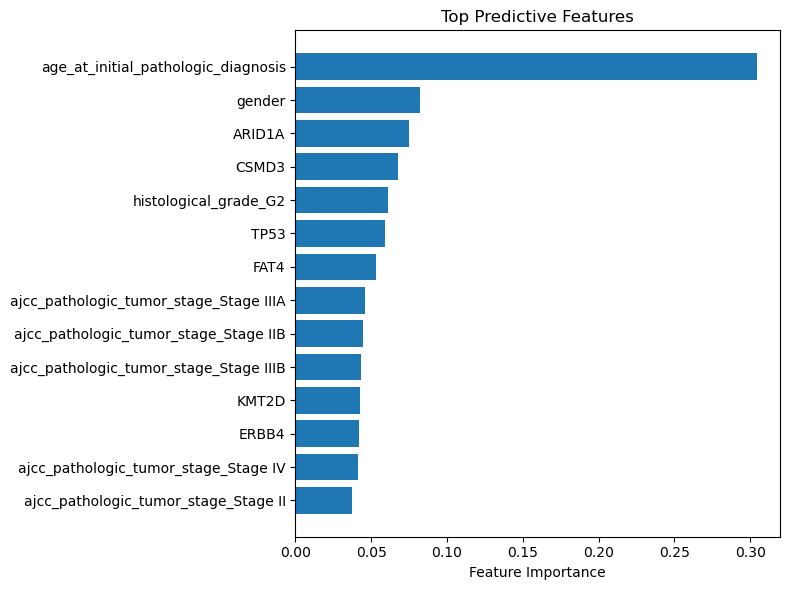

In [11]:
importances = best_rf.feature_importances_
feat_names = X_train.columns[sel.get_support()]
indices = np.argsort(importances)[::-1][:20]  # Top 20

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices][::-1], align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices][::-1])
plt.xlabel('Feature Importance'); plt.title('Top Predictive Features')
plt.tight_layout(); plt.show()
